# Regresión Lineal — Resumen visual
### Predicción del Éxito Académico en Educación Superior


**Tarea:** Predecir `nota_media_2sem` (calificación media del 2º semestre)  
**Modelos comparados:** Regresión Lineal con Ridge (L2) y Lasso (L1)  
**Estrategia de selección:** `GridSearchCV` con validación cruzada 5-fold  
**Métrica principal:** RMSE (penaliza errores grandes) + R² (varianza explicada)  
**Predictores:** perfil del alumno + contexto socioeconómico + rendimiento del 1er semestre  
**Variables excluidas:** 5 columnas del 2º semestre → evitar data leakage respecto al target


---
## 1. Búsqueda de hiperparámetros — GridSearchCV


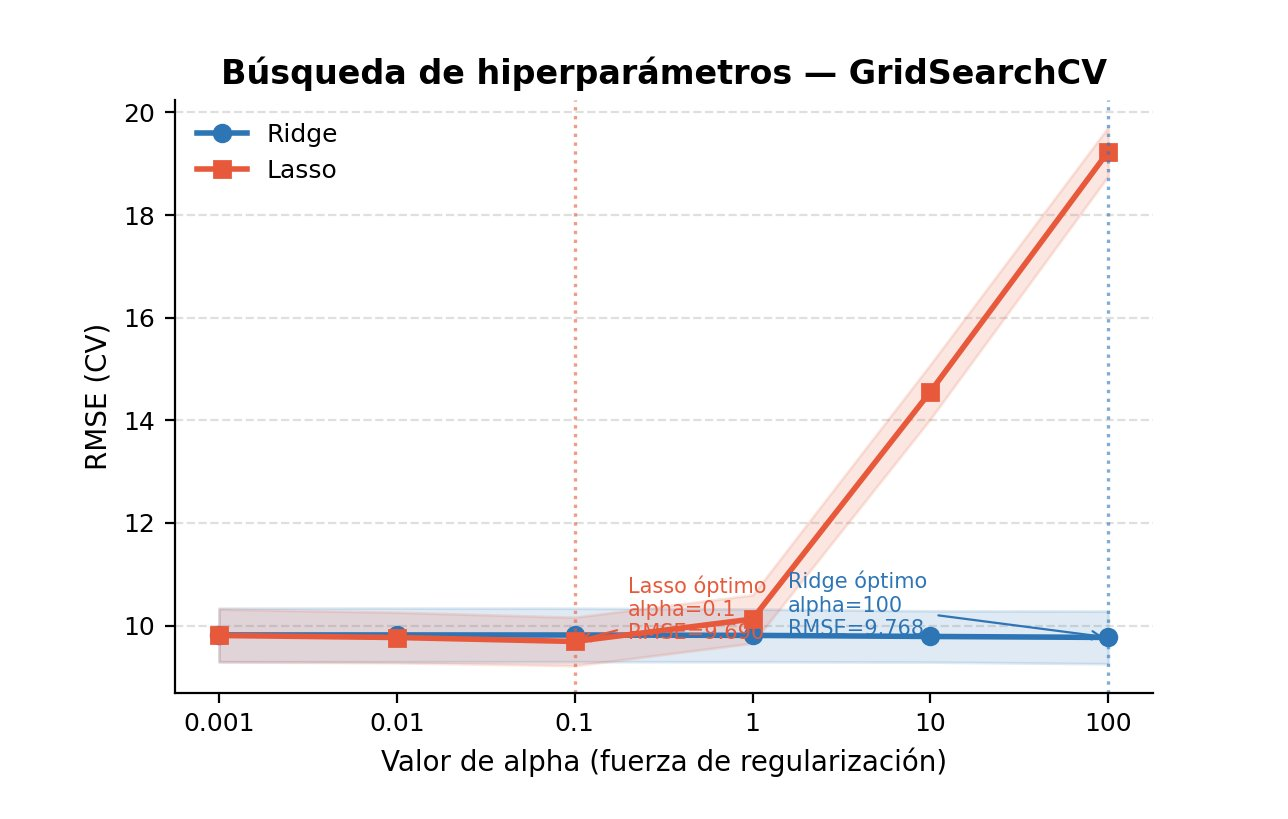

In [ ]:
# Figura generada por linear_regression.py

**¿Qué vemos?**
> Estamos viendo la evolución del RMSE en validación cruzada cuando variamos la fuerza de regularización usando Lasso y Rdige. Un alpha pequeño implica significa poca regularización (modelo más libre para sobreajustar) mientras que un alpha grande significa que aplicamos una regularización fuerte.

> Algo que salta mucho a la vista es el comportamiento totalmente distinto de los dos modelos. Ridge suele permanecer plano en torno a RMSE = 9.8 duranto todo el rango explorado. Sin embargo, Lasso presenta esa misma estabildiad solo hasta alpha=0.1 y a partir de ahí se dispara de forma brusca hasta RMSE = 10 con alpha= 100

> La clave para entender esta diferencia de comportamiento es que Ridge penaliza el cuadrado de los coeficientes: por mucho que la fuerza de regularización los coeficientes siempre se reducen proporcionalmente pero nunca llegan a anularse. Por tanto, el modelo consigue tener una representación distribuida de todas las features. Lasso en cambio penaliza el valor absoluto lo que provoca que con alphas altos empiece a anular muchos coeficientes informativos.

> Esto nos dice muchas cosas nuevas del dataset. La primera es que s. Ya que si hubiera muy pocas features muy dominantes el error no aumentaría así de fuerte si aumentamos la fuerza regularizadora. Por tanto hay un conjunto relevante de variables que, tomadas juntas, explican la nota del segundo semestre pero que ninguna por sí sola es suficiente

**¿Por qué RMSE negativo en GridSearchCV?**
> GridSearchCv está diseñado para maximizar la métrica pero la métrica usada mide un error por tanto queremos minimizarla lo maximizarla. Usando neg_root_mean_squared_error maximizamos el valor negativo que equivale a minimizar el RMSE real.

**Mejor configuración encontrada:**
> Ridge: `alpha=100` | RMSE (CV) = 9.768  
> Lasso: `alpha=0.1` | RMSE (CV) = 9.690  
> El alpha óptimo de Ridge es 100 y eso es algo sorprendente ya que significa que se necesita una regularización muy fuerte para que funcione bien. Eso traduce perfectamente algo que ya sabíamos de resultados obtenidos en clasificación: nuestro dataset tiene mucha colinealidad de variables. Por tanto si la regularización no es muy fuerte, Ridge  distribuye coeficientes grandes e inestables entre features redundantes y eso amplifica el ruido. Con alpha= 100 se consigue comprimir esa inestabilidad pero vemos que aún así no se consigue un error mínimo tan bueno como con Lasso.
> El alpha óptimo de Lasso = 0.1 confirma lo ya visto en modelos de clasificación anteriores. Este tipo de regularización termina siendo el más óptimo ya que mantiene features realmente informativas y elimina esas redundancias que Ridge no conseguía hacer completamente. La conclusión es clara: la propiedad de selección atuomática de variables de Lasso es clave en este dataset ya que elimina redundancias que afectan negativamente a nuestro modelo si no son controladas con suficiente fuerza


---
## 2. Predicciones vs valores reales — Lasso (alpha=0.1)


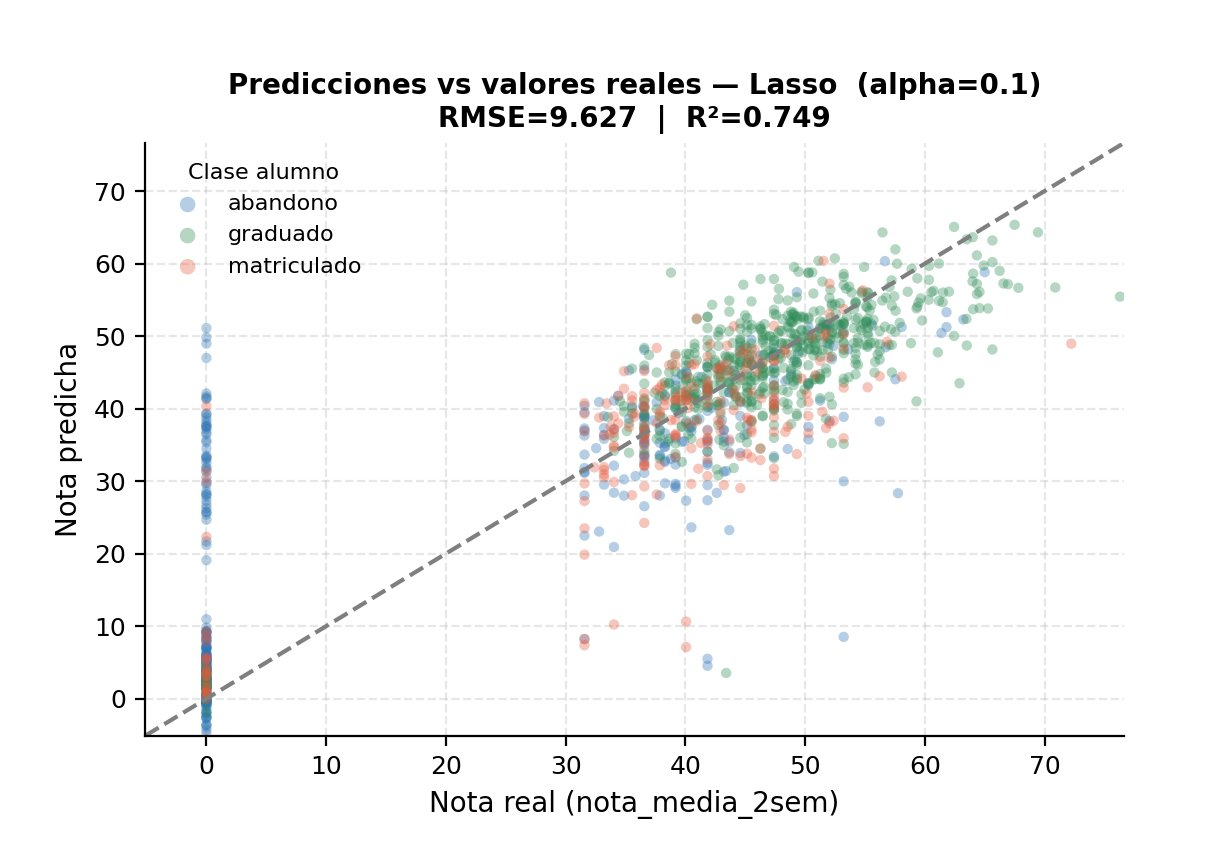

In [ ]:
# Figura generada por linear_regression.py

**¿Cómo leer esta gráfica?**
> Cada punto es un alumno del conjunto de test. El eje X es su nota real en el 2º semestre y el eje Y la nota que predice el modelo. Los puntos sobre la diagonal punteada son predicciones perfectas. Cuanto más nos alejamos de ella, mayor es el error cometido. El color indica la clase final del alumno (graduado, abandono, matriculado).  

**RMSE = 9.627 | R² = 0.749**
> Un R2 = 0.749 singifica que el modelo consigue explicar 74,9% de la varianza de la nota del segundo semestre usando solo datos sobre el perfil del alumno, su contexto socioeconómico y su rendimiento del 1er semestre. El 25.1% restante es varianza no explicada pero eso no significa que el modelo funcione mal es simplemente algo que vive en otras features que podemos no tomar en cuenta entre nuestros datos de entrada o incluso por una aleatoriedad misma de la realidad que no podemos captar por muchas features que usemos. Pueden ocrurrir decisiones personales del alumno a mitad de semestre o cambios en la situación familiar drástico que son muy complicados de captar incluso con tantas features de entrada.
> Un RMSE de 9.627 cuando la nota va de una escala de 0 a más o menos 75 podría parecer alto y realmente lo es. Entenderemos después que un problema en la naturaleza del problema amplificado por nuestra fórmula del error explica este resultado.

**El caso crítico: la columna vertical en x=0**
> Llegamos a lo más sorprendente que podemos obtener en los resultados del modelo. Hay una linea clara en x = 0. Esa posición en el eje x representa los alumnos cuya nota_media_2sem real es 0 lo que significa que no se presentaron a ninguna evaluación del 2do semestre, es decir abandonaron. Sin embargo, el modelo predice notas entre 20 y 50 provocando fallos enormes que son los que explican ese RMSE tan alto del que hemos hablado anteriormente. Este comportamiento se explica debido a que el modelo nunca tuvo acceso a la etiqueta de "abandono" durante el entrenamiento de regresión: solo vió la nota del 1er semestre, sus asignaturas aprobadas,su PIB ... Con esa información muchos alumnos parecen estudiantes normales e incluso bastante buenos y por eso el modelo predice una nota coherente con el perfil disponible. El abandono fue entonces seguramente una decisión posterior que ninguna variable de nuestro dataset ha podido anticipar.

> En clasificación era más fácil clasificar "abandono" debido a que teníamos variables del 2do semestre que delataban más el abandono. Como en regresión las hemos tenido que excluir por data leakage hemos perdido en gran parte lo que nos permitía identificar correctamente a los abandonos. Esto nos dice algo importante del dataset, el perfil previo no es suficientemente revelador como para predecir el abandono. Por tanto, por muchas features socioeconómicas que tenemos en el dataset, la realidad es que lo que más regía las decisiones del modelo eran las features académicas del segundo semestre.

**Comportamiento por clase:**
> Los graduados (verde) son los que mejor sigue el modelo. La nube verde es la que mejor se ajusta a la diagonal (predicción = realidad). Tiene sentido ya que tienen perfiles académicos más consolidados y situaciones económicas más propensas a tener notas fácilmente predecibles por nuestro modelo
> Los matriculados tienen más dispersión alrededor de la diagonal y eso cuadra bastante con las conclusiones sacadas en clasificación. Al ser una clase de tránsito, tenemos perfiles más distintos (algunos más cerca de abandono y otros más cerca de graduado).
> Los abandonos, fuera de esa columna vertical que hemos explicado, están razonablemente bien captados por el modelo. Son alumnos que abandonaron pero sí obtuvieron nota en el segundo semestre. Esto confirma que el problema de la columna vertical no es algo "general" con los abandonos sino específicamente con los que tienen nota=0 (no se presentaron).



---
## 3. Distribución de residuos


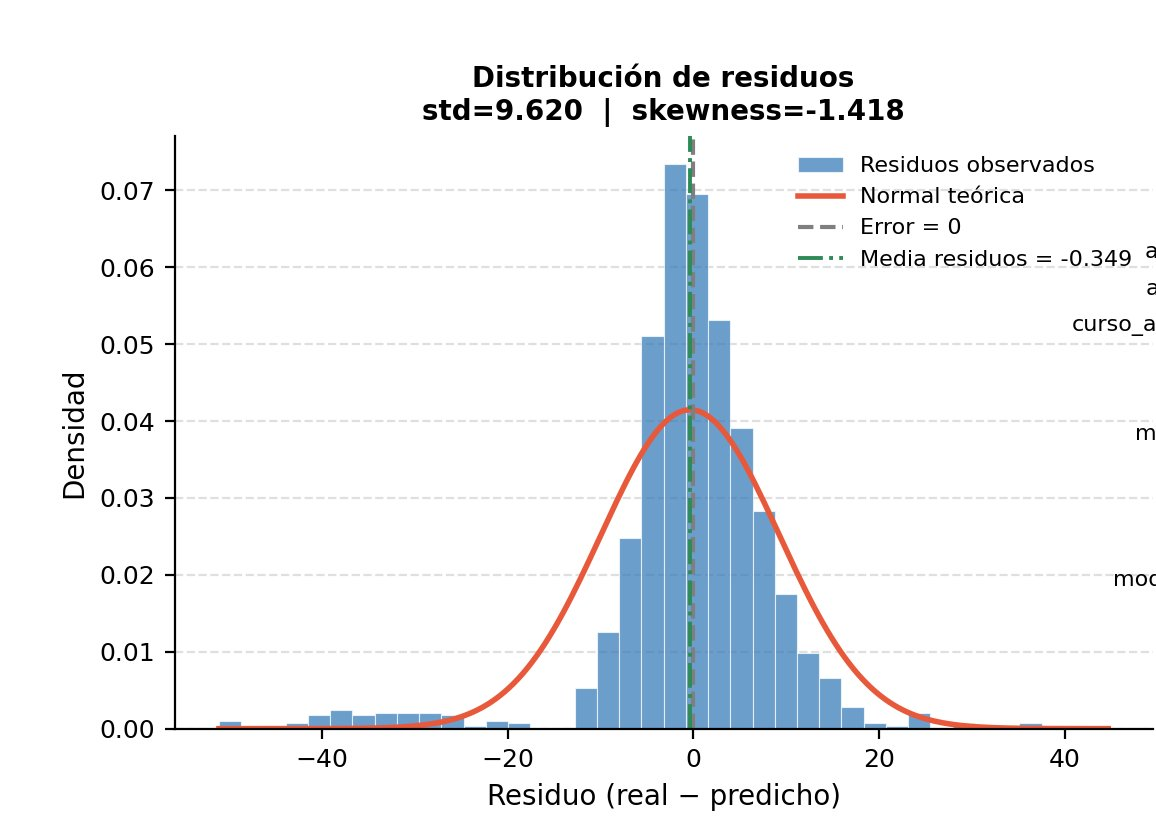

In [ ]:
# Figura generada por linear_regression.py

**¿Qué son los residuos y cómo leerlos?**
> El residuo de cada predicción es real - predicho. un modelo de regresión lineal bien ajustado debería producir residuos distribuidos de forma aproximadamente normal centrada en 0. Este diagnóstico es específico de regresión ya que en clasificación no tiene sentido hablar de distribución de errores al predecir categorías discretas. En regresión es clave hacer este análisis ya que nos indica si el modelo lineal es el correcto para este problema o si hay patrones que no se capturan 

**std = 9.620 | skewness = −1.418**
> La asimetría negativa que encontramos no nos sorprende después de lo que hemos explicado en la gráfica anterior: es la consecuencia directa de esa columna vertical en x= 0. Esos alumnos con nota real 0 generan residuos muy negativos que forman esa cola izquierda en el histograma. La conclusión es la misma que antes, el sesgo del modelo no es algo aleatorio ni es generalizado sino que está concentrado en un subgrupo específico por una razón en la naturaleza misma del problema. Algo interesante que podremos tratar en la parte final del proyecto es ver el impacto que tiene sobre los resultado si eliminamos del conjunto de test todos los alumnos con nota real 0.




---
## 4. Top 15 coeficientes — Lasso (alpha=0.1)


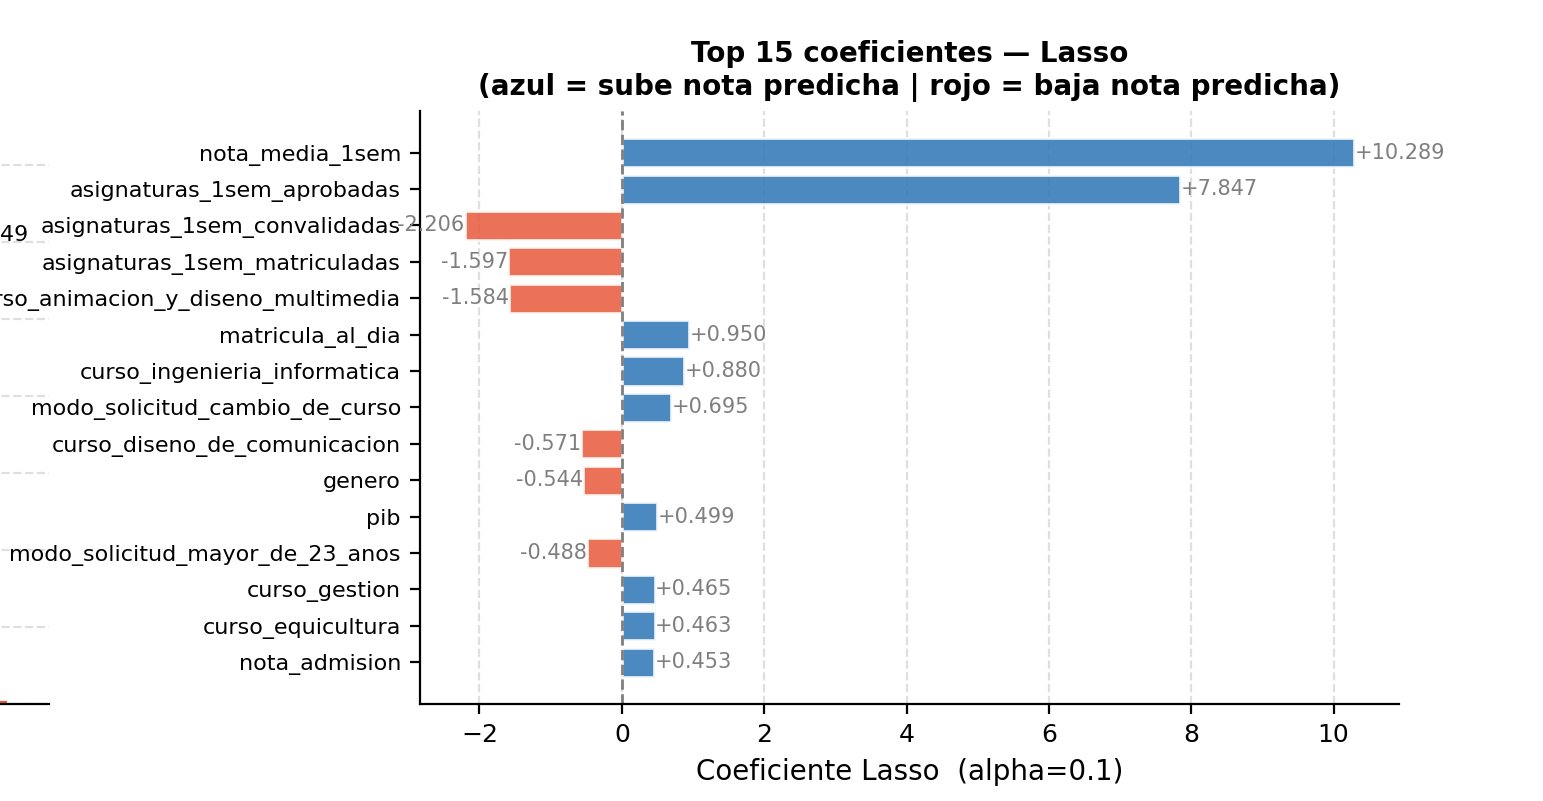

In [ ]:
# Figura generada por linear_regression.py

**¿Qué representan estos coeficientes?**
> Lasso asigna un coeficiente a cada feature. Su signo indica la dirección del efecto sobre la nota predicha del 2º semestre (azul = sube la nota, rojo = la baja) y su magnitud indica la intensidad. Las features con coeficiente = 0 han sido eliminadas automáticamente por Lasso al considerarlas no informativas o redundantes dado el nivel de regularización alpha=0.1. Los valores están sobre datos estandarizados, por lo que los coeficientes son comparables entre sí.  

**`nota_media_1sem` (+10.289) y `asignaturas_1sem_aprobadas` (+7.847):**
> Ambas variables dominan con gran diferencia respecto al resto de las features lo que nos deja una conclusión muy clara: el rendimiento académico del 1er semestre es el mejor predictor del rendimiento del 2do semestre. Esto es algo que intuíamos al ver cómo el modelo predecía muchas notas de 0 como mucho más elevadas a pesar de tener variables socioeconómicas que podían hacerle pensar más en la posibilidad de abandono. Esto podría parecer contradictorio con lo que observamos en la gráfica de GridSearchCV donde concluíamos que la señal predictiva estaba distribuida entre muchas variables. La aparente contradicción se resuelve al distinguir dos niveles: nota_media_1sem y asignatures_1sem_aprobadas son claramente más importantes pero no son suficientes por sí solas para explicar el 74.9 % de la varianza que captura el modelo. El resto de R2 lo construyen otras variables restantes activas sumando contribuciones pequeñas pero reales sin que ninguna de ellas domine individualmente pero que "en conjunto" añaden información que las dos primeras no capturan.

> Que ambas variables tengan coeficientes altos y postivos siendo conceptualmente similares significa que Lasso ha decidido mantener las dos activas y eso nos dice que aportan información complementaria. La nota media captura la calidad del rendimiento mientras que las aprobadas captruan la amplitud (puedes tener muchas aprobadas con nota baja). Juntas describen mejor al alumno que cualquier por separado


**`asignaturas_1sem_convalidadas` (−2.206) y `asignaturas_1sem_matriculadas` (−1.597):**
> Las convalidadas tiene coeficiente negativo porque un alumno con muchas asignaturas convalidadas en el 1er semestre tiene una carga cadémica mucho menor. Por tanto nota_media_1sem y asignaturas_1sem_aprobadas reflejan entonces solo las pocas asignaturas que sí cursó y eso es una base más estrecha para predecir el segundo semestre. Además, muchos alumnos con convalidaciones vienen de otras carreras con perfiles más heterogéneos y por tanto menos predecible

> Las matriculadas con coeficiente negativo también revelan que matricularse en muchas asingaturas no implica aprobarlas. Si un alumno se matricula en 8 asignaturas pero aprueba 5 tiene un perfil de sobrecarga que se asocia a peo rendimiento en el segundo semestre

**Variables socioeconómicas con coeficiente activo (`matricula_al_dia`, `genero`, `pib`):**
> Lasso elimina muchas variables socioeconómicas pero mantiene algunas como estas. Eso significa que tienen bastante poder predictivo y son un reflejo de la influencia de factores externos al simple rendimiento académico en la nota del segundo semestre. 

>La matricula al día implica mejor nota en segundo semestre y eso tiene una explicación muy lógica:  un alumno que ya tiene problemas de pago en el 1er semestre carga con mucho estrés extracadémico que le afecta en el rendimiento del segundo semestre.

>El género apunta a que los hombres obtienen una media de nota algo menor en el segundo semestre y eso es coherente con algo notable en la educación en contextos europeos: las mujeres tienden a mostrar mayor consistencia entre semestres y menor variabilidad en el rendimiento.

>Entran también en consideracíon más variables económicas como el pib o el modo de solicitud...



---
## 5. Conclusión — Regresión Lineal

<div style="border: 2px solid #2e86c1; border-radius: 8px; padding: 20px 24px; margin: 28px 0; background-color: #eaf4fb; color: #000000;">
<h3 style="color: #1a5276; margin-top: 0; padding-bottom: 8px; border-bottom: 1px solid #aed6f1; margin-bottom: 14px;">Conclusiones finales — Regresión Lineal</h3>

Conclusiones finales trás el análisis de los resultados en el notebook:
El modelo de regresión lineal sobre este dataset ha demostrado ser una herramienta no solo predictiva sino diagnóstica. El R2= 0.749 que hemos obtenido con Lasso con alpha = 0.1 confirma que el conjunto de features que representan el primer semestre académico y algunos factores socioeconómicos han anticipado razonablemente bien la nota predicha del 2do semestre. Sin embargo, los resultados analizados en el notebook revelan varios factores interesantes que explican el comportamiento obtenido y exponen algunas limitaciones reales del problema.

La selección de hiperparámetros ha sido el primer elemento diagnóstico: el alpha= 100 óptimo para Ridge nos ha permitido confirmar esas colinealidad elevada del dataset ya identificada en clasificación. De hecho, la función regularizadora óptima hallada es Lasso y eso cuadra perfectamente debido a su selección automática de variables redundantes. Además, el claro empeoramiento del rendimiento de Lasso con regularización alta delata que la señal predictiva está distribuida entre muchas variables con contribuciones moderadas y que en cuanto las eliminamos generan resultados mucho menos competentes.

El análisis de predicciones vs valores reales revela un hallazgo muy importante: una columna vertical en x=0 en la que el modelo obtiene errores grotescos. Esos datos representan los alumnos que abandonaron sin presentarse al 2do semestre y terminan generando muchos errores debido a que su perfil del 1er semestre es indistinguible del de un alumno normal. Este resultado nos dice algo importante sobre nuestros datos: el abandono en este dataset no es predecible con las variables disponibles antes del 2do semestre. Este problema no lo teníamos en clasificación debido a que sí teníamos las variables del 2do semestre que aumentaban mucho la capacidad discriminativa del modelo y delataban fácilmente al alumno con perfil de abandono. Esto nos demuestra que las variables socioeconómicas del dataset, aunque son informativamente valiosas, no son suficientes para anticipar el abandono que en muchos casos responde a decisiones más personales o situaciones no capturables con las features que recibimos en el dataset.
Otro análisis propio al hecho de que predecimos un target numérico continuo es que debemos verificar si se cumple una aparente normalidad de los errores para confirmar que un modelo lineal es conveniente. Al analizar los resultados observamos una cierta asimetría negativa que es la firma estadística del problema explicado anteriormente en la columna de x=0. Por tanto, suponemos que borrando los alumnos cuya nota en target sea 0 obtendremos mayor normalidad en los errores y por tanto mejores métricas (lo incluiremos en otra parte del proyecto).
Finalmente, exploramos una de las ventajas de la regresión lineal que es la fácil interpretación de sus coeficientes para entender qué factores han influenciado más en la predicción de la nota media del segundo semestre. Hemos llegado a varias conclusiones de distinta naturaleza:
La primera es técnica: la señal predictiva tiene dos niveles, el primer nivel es que tiene dos variables dominantes que son la nota_media_1sem y asignaturas_1sem_aprobadas que traducen una realidad muy clara: el rendimiento académico del 1er semestre es el mejor predictor del 2do semestre. El segundo nivel reside en la presencia de un conjunto de variables con contribuciones parecidas y moderadas pero que son igual de importantes en conjunto que las otras dos primeras ya que hemos visto que en cuanto nos pasamos regularizando desaparecen y el error aumenta muchísimo. Por tanto podríamos concluir que los 3 ejes principales a la hora de determinar la nota media del segundo semestre son la nota_media_1sem , las asignaturas _1sem_aprobadas y un conjunto de variables socioeconómicas cuya importancia individual es menor pero cuyo conjunto representa relevancia clave para el modelo. Entre esas variables encontramos: matricula al dia que influye sobre el estrés económico añadido sobre el estudiante que puede empeorar sus resultados o también género que revela algo muy típico en el sistema educativo europeo que es la mayor consistencia entre semestre de las mujeres. Lo que hace especialmente relevante este segundo nivel de variables es que son de naturaleza socioeconómica, no académica. Que Lasso las mantenga activas en su selección de variables significa que el rendimiento universitario no es puramente académico y el contexto económico y personal del alumno tiene un efecto medible sobre sus resultados.


</div>